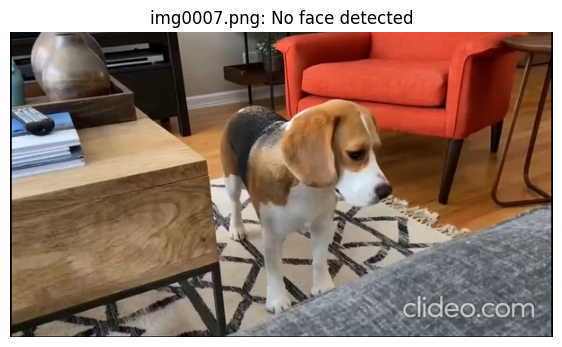

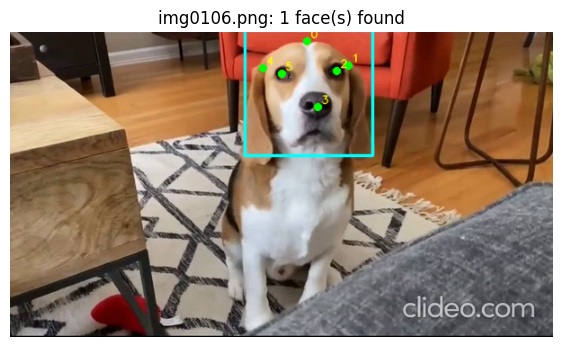

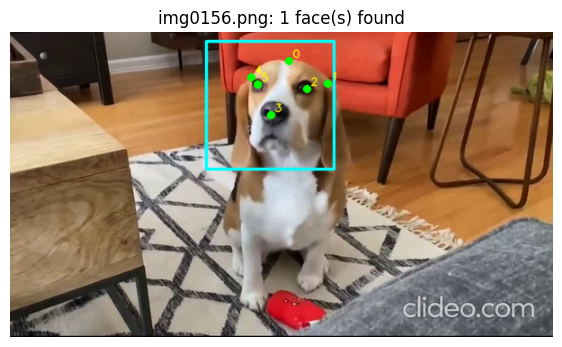

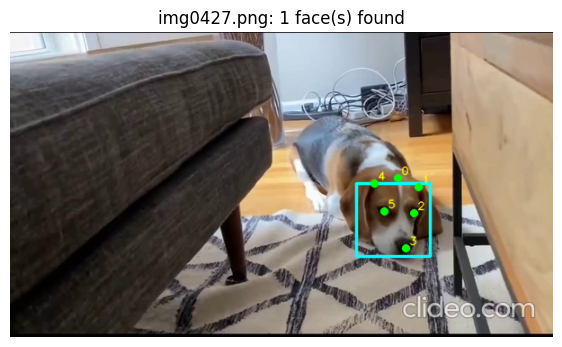

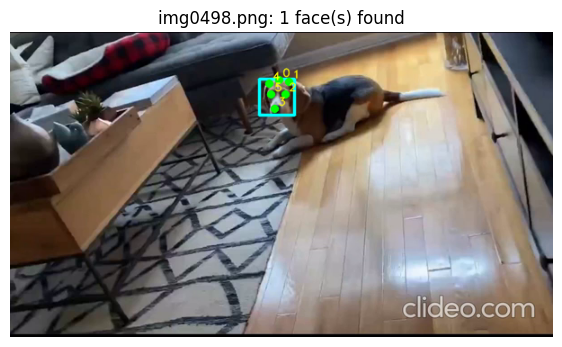

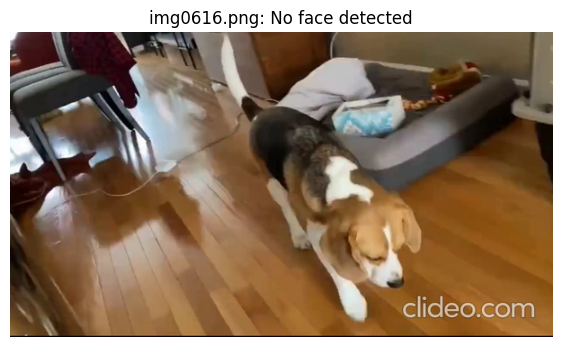

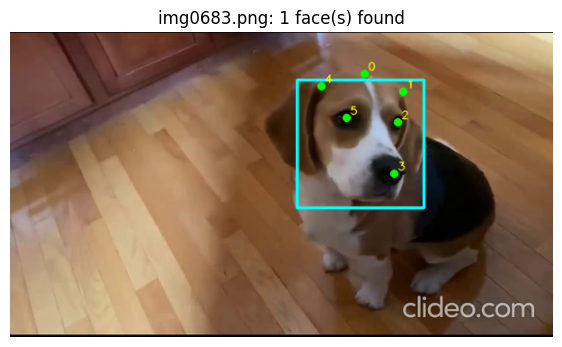

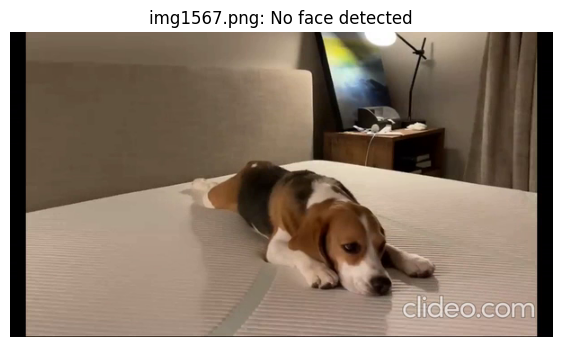

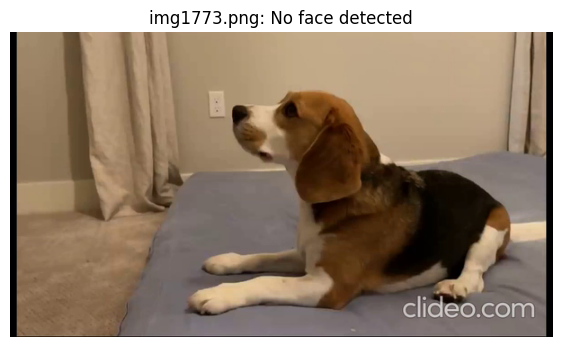

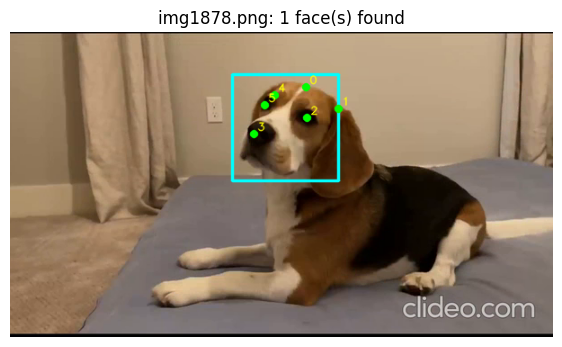

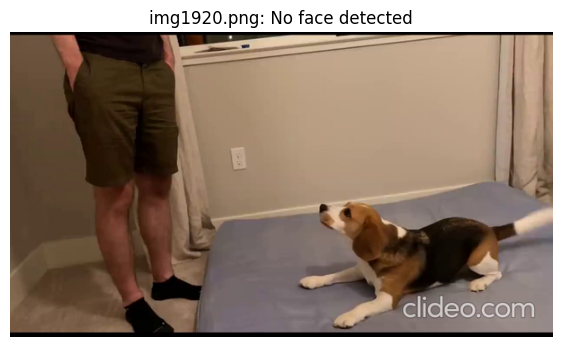

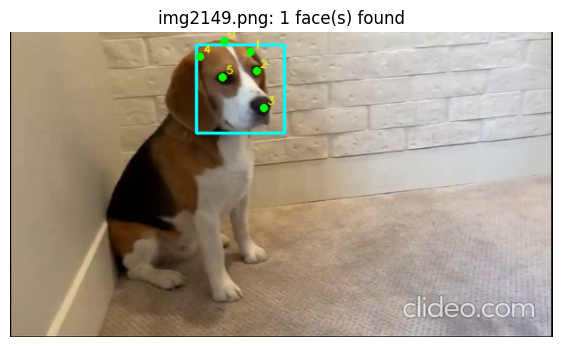

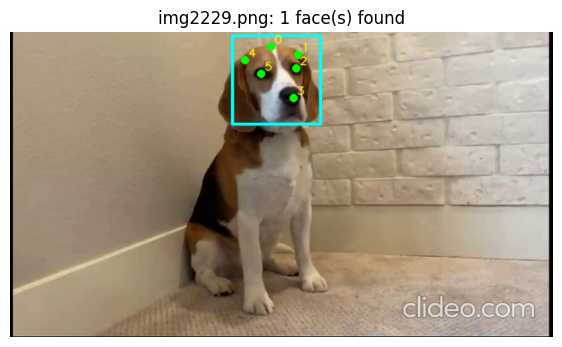

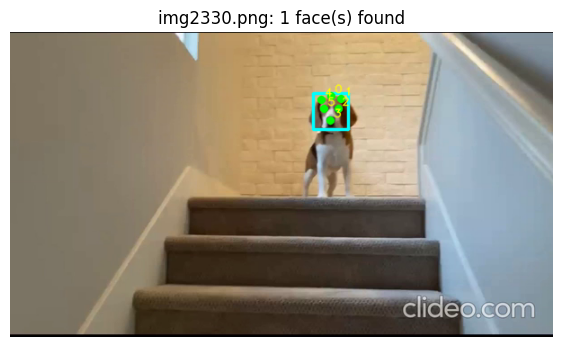

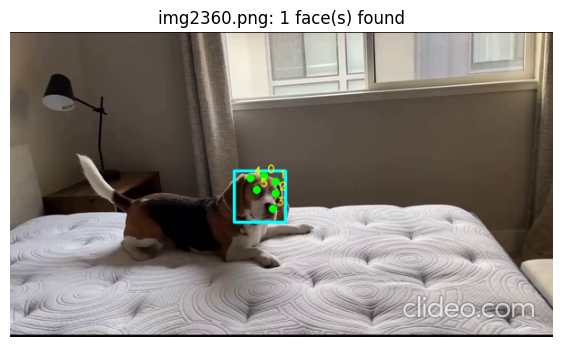

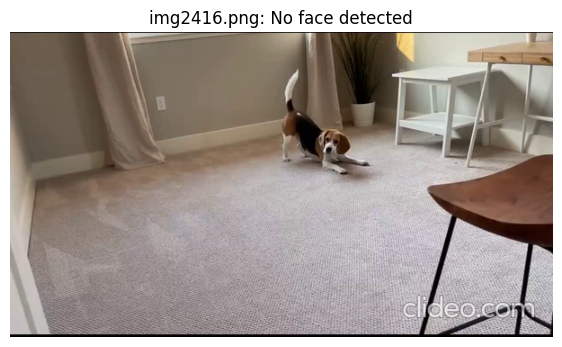

In [68]:
import os
import glob
import cv2
import dlib
import matplotlib.pyplot as plt
from imutils import face_utils


# 1. Model Initialization
DETECTOR_PATH = "/content/dogHeadDetector.dat"
PREDICTOR_PATH = "/content/landmarkDetector.dat"

detector = dlib.cnn_face_detection_model_v1(DETECTOR_PATH)
predictor = dlib.shape_predictor(PREDICTOR_PATH)


# 2. Directory & Path Setup

INPUT_DIR = "/content/all_16_images"
OUTPUT_DIR = "/content/annotated_deliverables"
os.makedirs(OUTPUT_DIR, exist_ok=True)

image_paths = sorted(
    glob.glob(os.path.join(INPUT_DIR, "*.[jJ][pP][gG]")) +
    glob.glob(os.path.join(INPUT_DIR, "*.[pP][nN][gG]"))
)

# Semantic index mapping for the 6 landmark coordinates
LANDMARK_NAMES = {
    0: "Right Ear",
    1: "Left Ear",
    2: "Nose Bridge",
    3: "Snout Tip",
    4: "Right Eye",
    5: "Left Eye"
}


# 3. Two-Stage Detection & Landmark Pipeline

for img_path in image_paths:
    bgr_img = cv2.imread(img_path)
    if bgr_img is None:
        continue

    # Convert BGR to RGB (required by Dlib models)
    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    canvas = rgb_img.copy()

    # Stage 1: Face Detection (upsample=1 to detect smaller heads in the frame)
    detections = detector(rgb_img, upsample_num_times=1)

    for d in detections:
        rect = d.rect
        x1, y1 = rect.left(), rect.top()
        x2, y2 = rect.right(), rect.bottom()

        # Draw bounding box (Cyan)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 255), 2, lineType=cv2.LINE_AA)

        # Stage 2: Landmark Alignment inside the localized box
        shape = predictor(rgb_img, rect)
        landmarks = face_utils.shape_to_np(shape)

        # Draw the 6 facial landmarks (Green circles with Yellow ID labels)
        for i, (lx, ly) in enumerate(landmarks):
            cv2.circle(canvas, (int(lx), int(ly)), 4, (0, 255, 0), -1, lineType=cv2.LINE_AA)
            cv2.putText(
                canvas, str(i), (int(lx) + 4, int(ly) - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1, lineType=cv2.LINE_AA
            )

    # Save annotated deliverable to disk
    out_file = os.path.join(OUTPUT_DIR, os.path.basename(img_path))
    cv2.imwrite(out_file, cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

    # Display result inline
    plt.figure(figsize=(7, 7))
    plt.imshow(canvas)
    status = f"{len(detections)} face(s) found" if len(detections) > 0 else "No face detected"
    plt.title(f"{os.path.basename(img_path)}: {status}")
    plt.axis("off")
    plt.show()

Question 2

In [69]:
# Download the dataset from the give Google drive link
!pip install gdown
!gdown --id 1tWr3DQ9L7h8AdghrZ67ArJXjaxR7V4Wi -O vanishing_points.zip
!unzip -q vanishing_points.zip -d /content/vp_dataset/

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1tWr3DQ9L7h8AdghrZ67ArJXjaxR7V4Wi
To: /content/vanishing_points.zip
100% 597k/597k [00:00<00:00, 5.77MB/s]
replace /content/vp_dataset/Estimate_vanishing_points_data/1603176284-vanishingpoint.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


/tmp/ipykernel_8373/705303196.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


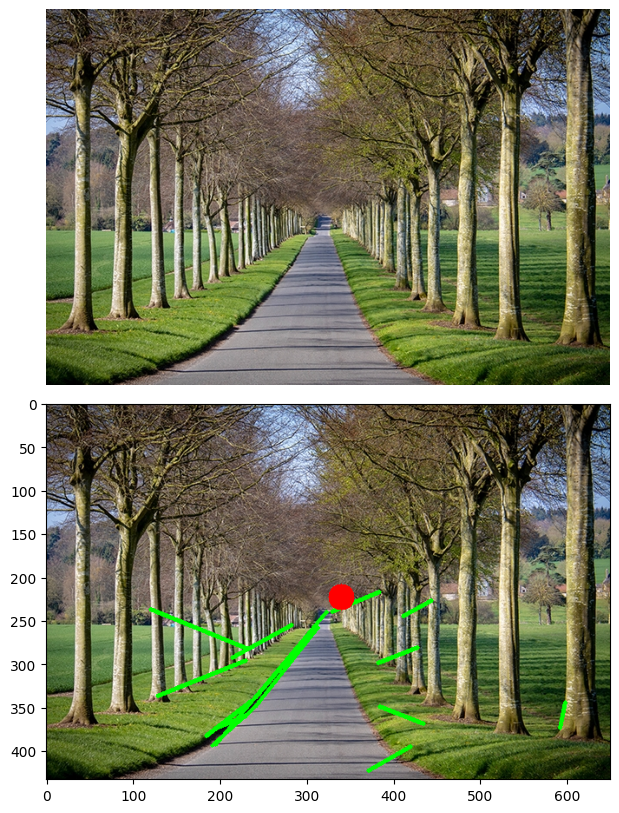

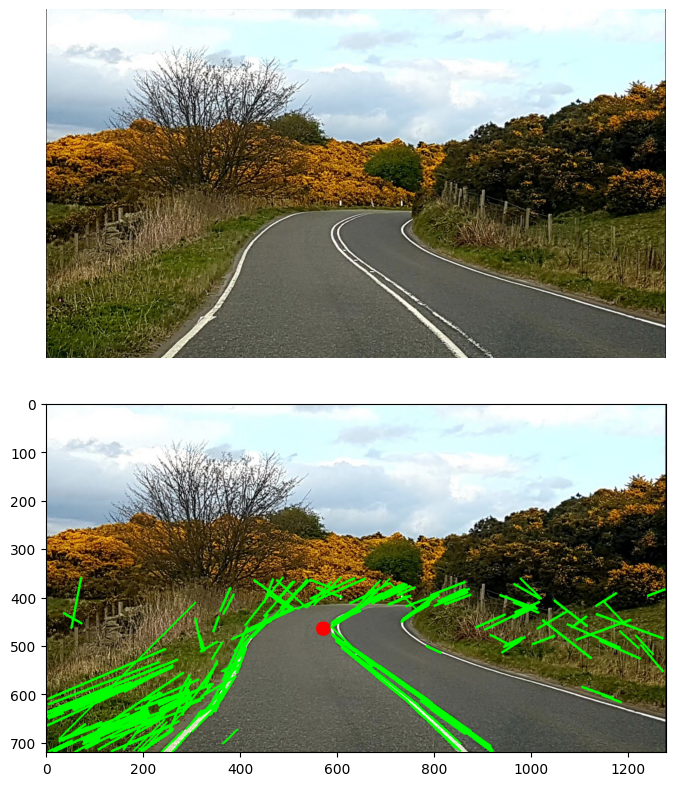

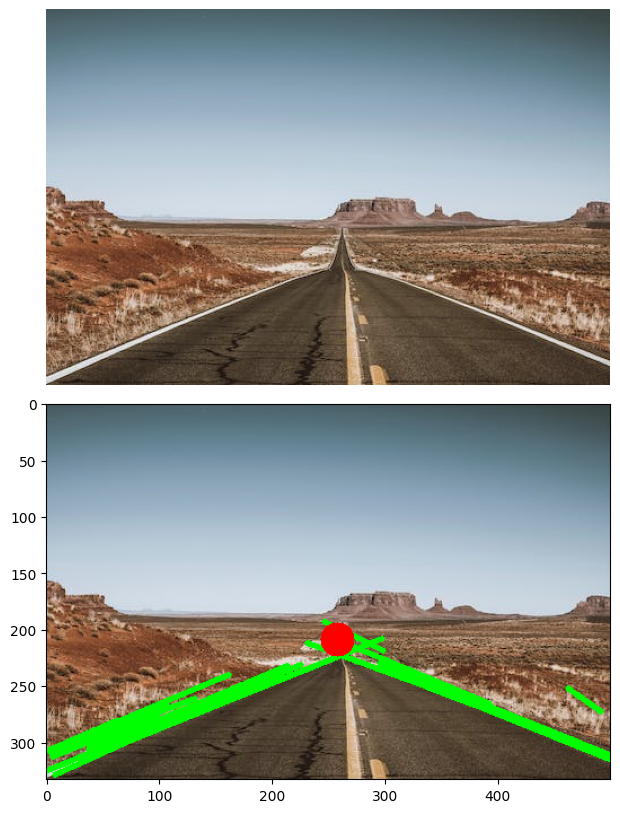

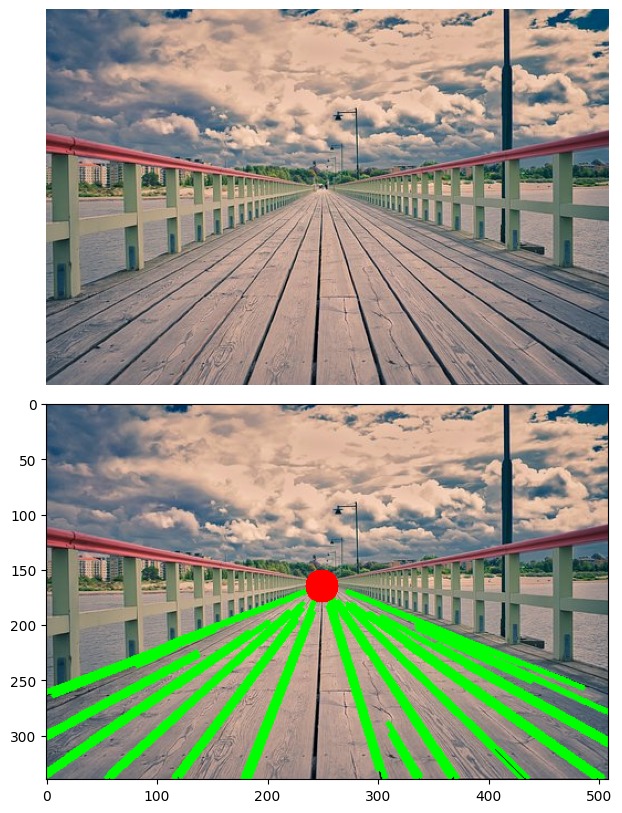

In [70]:
import cv2
import math
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Geometry Helper Functions ---
def line_eq(p1, p2):
    """Converts two points into standard line form: ax + by + c = 0"""
    return (p1[1] - p2[1]), (p2[0] - p1[0]), (p1[0]*p2[1] - p2[0]*p1[1])

def intersect(l1, l2):
    """Finds intersection of two standard lines using Cramer's rule."""
    det = l1[0] * l2[1] - l2[0] * l1[1]
    if abs(det) < 1e-6: return None
    return int((l1[1]*l2[2] - l2[1]*l1[2])/det), int((l2[0]*l1[2] - l1[0]*l2[2])/det)

def dist(pt, l):
    """Calculates perpendicular distance from a point to a standard line."""
    return abs(l[0]*pt[0] + l[1]*pt[1] + l[2]) / (math.hypot(l[0], l[1]) + 1e-6)

# --- RANSAC Algorithm ---
def ransac_vp(lines, shape, iters=500, thresh=15.0):
    """Estimates the vanishing point using RANSAC with a spatial horizon constraint."""
    h, w = shape[:2]
    std_lines = [line_eq((x1, y1), (x2, y2)) for x1, y1, x2, y2 in lines]
    best_vp, max_inliers = None, 0

    for _ in range(iters):
        l1, l2 = random.sample(std_lines, 2)
        pt = intersect(l1, l2)
        if not pt: continue

        # Spatial constraint: Vanishing point must be in the top 65% of the image (horizon)
        if not (-w <= pt[0] <= w*2 and -h <= pt[1] <= h*0.65): continue

        inliers = sum(1 for line in std_lines if dist(pt, line) <= thresh)
        if inliers > max_inliers:
            max_inliers, best_vp = inliers, pt

    return best_vp

# --- Main Pipeline ---
image_paths = [p for p in sorted(glob.glob("/content/vp_dataset/**/*.*", recursive=True))
               if p.lower().endswith(('.jpg', '.png', '.jpeg'))]

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None: continue

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # 1. Edge Detection
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 1.5), 40, 120)

    # 2. ROI Masking (Process only the bottom 50% where the road is)
    mask = np.zeros_like(edges)
    cv2.rectangle(mask, (0, int(h * 0.50)), (w, h), 255, -1)
    masked_edges = cv2.bitwise_and(edges, mask)

    # 3. Hough Line Transform
    raw_lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 30, minLineLength=30, maxLineGap=15)

    # 4. Angle Filtering (Isolate perspective lines)
    p_lines = []
    if raw_lines is not None:
        for seg in raw_lines:
            x1, y1, x2, y2 = seg[0]
            angle = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))
            if (20 <= angle <= 80) or (100 <= angle <= 160):
                p_lines.append((x1, y1, x2, y2))

    # 5. Draw Annotations
    canvas = rgb.copy()
    for x1, y1, x2, y2 in p_lines:
        cv2.line(canvas, (x1, y1), (x2, y2), (0, 255, 0), 3)

    if len(p_lines) >= 2:
        vp = ransac_vp(p_lines, (h, w))
        if vp: cv2.circle(canvas, vp, 15, (255, 0, 0), -1)

    # 6. Visualization
    fig, axes = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'hspace': 0.05})
    axes[0].imshow(rgb); axes[0].axis('off')
    axes[1].imshow(canvas)
    plt.tight_layout()
    plt.show()